H0=69.4 km/s/Mpc, b=-14.5, chi2r=0.68


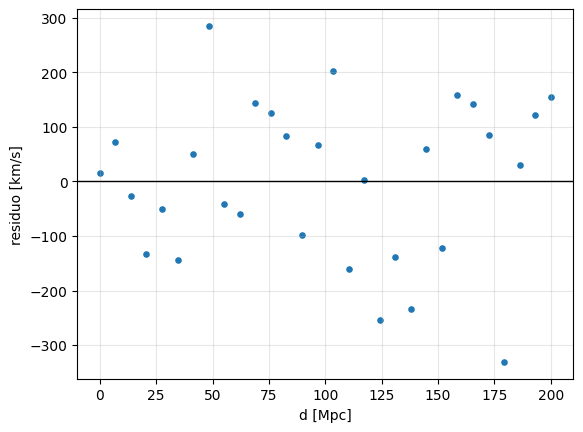

In [1]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(7)
H0_true, sigma_v = 70.0, 180.0
d = np.linspace(0, 200, 30)
v_obs = H0_true*d + rng.normal(0, sigma_v, d.size)

m, b = np.polyfit(d, v_obs, 1)
v_fit = m*d + b
res = v_obs - v_fit
chi2r = np.sum((res/sigma_v)**2)/(d.size-2)
print(f"H0={m:.1f} km/s/Mpc, b={b:.1f}, chi2r={chi2r:.2f}")

plt.scatter(d, res, s=14)
plt.axhline(0, color='k', lw=1)
plt.xlabel('d [Mpc]'); plt.ylabel('residuo [km/s]')
plt.grid(alpha=0.3); plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos originales (del ejemplo anterior)
rng = np.random.default_rng(42)
x = np.linspace(0, 10, 25)
y_true = 2.5 * x + 5.0

# Crear incertidumbres variables para cada punto
rng2 = np.random.default_rng(0)
sigma_i = rng2.uniform(1.0, 3.0, size=x.size)  # σ entre 1 y 3

# Generar observaciones con ruido proporcional a sigma_i
y_obs = y_true + rng.normal(0, 1, size=x.size) * sigma_i

In [2]:
# Ajuste estándar: todos los puntos pesan igual
m_sin, b_sin = np.polyfit(x, y_obs, deg=1)
y_fit_sin = m_sin * x + b_sin

print(f"\nAjuste SIN ponderación:")
print(f"  Pendiente m = {m_sin:.3f} (real: 2.500)")
print(f"  Intercepto b = {b_sin:.3f} (real: 5.000)")

# Calcular chi^2 sin ponderar (asumiendo σ=1 para todos)
res_sin = y_obs - y_fit_sin
chi2_sin = np.sum(res_sin**2)
print(f"  Suma de residuos² = {chi2_sin:.2f}")


Ajuste SIN ponderación:
  Pendiente m = 2.628 (real: 2.500)
  Intercepto b = 4.136 (real: 5.000)
  Suma de residuos² = 73.26


In [3]:
# Calcular pesos: w = 1/σ
w = 1.0 / sigma_i

# Ajuste ponderado: puntos precisos pesan más
m_con, b_con = np.polyfit(x, y_obs, deg=1, w=w)
y_fit_con = m_con * x + b_con

print(f"\nAjuste CON ponderación:")
print(f"  Pendiente m = {m_con:.3f} (real: 2.500)")
print(f"  Intercepto b = {b_con:.3f} (real: 5.000)")

# Calcular chi^2 ponderado correctamente
res_con = y_obs - y_fit_con
chi2_con = np.sum((res_con / sigma_i)**2)
print(f"  χ² ponderado = {chi2_con:.2f}")


Ajuste CON ponderación:
  Pendiente m = 2.484 (real: 2.500)
  Intercepto b = 5.183 (real: 5.000)
  χ² ponderado = 16.49


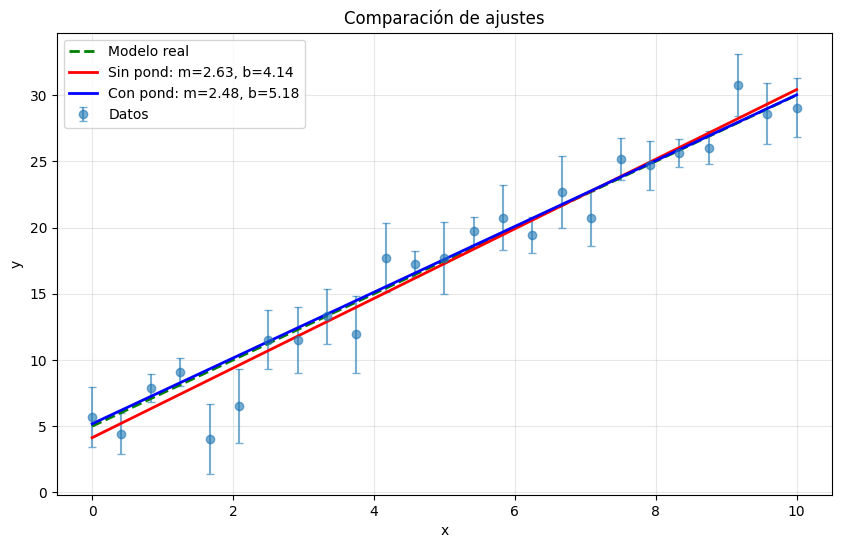

In [4]:
plt.figure(figsize=(10, 6))
# Graficar datos con barras de error
plt.errorbar(x, y_obs, yerr=sigma_i, 
             fmt='o', alpha=0.6, 
             label='Datos', capsize=3)
# Línea verdadera
plt.plot(x, y_true, 'g--', lw=2, 
         label='Modelo real')
# Ajuste sin ponderación
plt.plot(x, y_fit_sin, 'r-', lw=2, 
         label=f'Sin pond: '
               f'm={m_sin:.2f}, '
               f'b={b_sin:.2f}')

# Ajuste con ponderación
plt.plot(x, y_fit_con, 'b-', lw=2, 
         label=f'Con pond: '
               f'm={m_con:.2f}, '
               f'b={b_con:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Comparación de ajustes')
plt.show()